# Breakout/Bust Classifier Report (with Post-Hoc Calibration)

Comprehensive evaluation of the HistGradientBoostingClassifier that predicts P(breakout), P(bust), P(neutral) for each player based on preseason features and historical ADP-relative outcomes.

**New in this version:** Per-class isotonic regression calibration fitted via temporal expanding CV. Calibrates `p_breakout` and `p_bust` independently, then renormalizes all three probabilities to sum to 1.

**Label definitions** (default thresholds):
- **Breakout:** ADP rank - actual value rank >= 30 (drafted lower than actual performance)
- **Bust:** ADP rank - actual value rank <= -30 (drafted higher than actual performance)
- **Neutral:** everything else

**Seasons with both ADP and actual valuations:** 2019, 2021-2024

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import log_loss

from fantasy_baseball_manager.cli.factory import DbLabelSource
from fantasy_baseball_manager.db.connection import create_connection
from fantasy_baseball_manager.db.pool import SingleConnectionProvider
from fantasy_baseball_manager.features import SqliteDatasetAssembler
from fantasy_baseball_manager.models.breakout_bust.model import (
    _DEFAULT_FEATURE_COLUMNS,
    _FEATURE_SET_BUILDERS,
    LABEL_TO_INT,
    _collect_classification_fold_data,
    _join_labels_with_features,
    _renormalize_probabilities,
)
from fantasy_baseball_manager.models.gbm_training import extract_features
from fantasy_baseball_manager.models.sampling import temporal_expanding_cv
from fantasy_baseball_manager.models.statcast_gbm.calibration import (
    apply_calibrators,
    fit_multifold_calibrators,
)
from fantasy_baseball_manager.services.breakout_bust import label_distribution

warnings.filterwarnings("ignore")

conn = create_connection(Path("../data/fbm.db"))
provider = SingleConnectionProvider(conn)
assembler = SqliteDatasetAssembler(provider, statcast_path=Path("../data/statcast.db"))
label_source = DbLabelSource(conn)

SEASONS = [2019, 2021, 2022, 2023, 2024]
print(f"Using seasons: {SEASONS}")

Using seasons: [2019, 2021, 2022, 2023, 2024]


## 1. Label Distribution by Season

In [2]:
all_labels = {}
for season in SEASONS:
    all_labels[season] = label_source.get_labels(season)

dist_rows = []
for season in SEASONS:
    labels = all_labels[season]
    dist = label_distribution(labels)
    total = sum(dist.values())
    dist_rows.append(
        {
            "season": season,
            "breakout": dist["breakout"],
            "neutral": dist["neutral"],
            "bust": dist["bust"],
            "total": total,
            "breakout_pct": f"{dist['breakout'] / total:.1%}" if total else "0%",
            "bust_pct": f"{dist['bust'] / total:.1%}" if total else "0%",
        }
    )

dist_df = pd.DataFrame(dist_rows)
print(dist_df.to_string(index=False))

for ptype in ("batter", "pitcher"):
    print(f"\n--- {ptype.title()} ---")
    rows = []
    for season in SEASONS:
        labels = [ls for ls in all_labels[season] if ls.player_type == ptype]
        dist = label_distribution(labels)
        total = sum(dist.values())
        rows.append(
            {
                "season": season,
                "breakout": dist["breakout"],
                "neutral": dist["neutral"],
                "bust": dist["bust"],
                "total": total,
            }
        )
    print(pd.DataFrame(rows).to_string(index=False))

 season  breakout  neutral  bust  total breakout_pct bust_pct
   2019        52       37   185    274        19.0%    67.5%
   2021        58       33   184    275        21.1%    66.9%
   2022        58       47   174    279        20.8%    62.4%
   2023        62       45   176    283        21.9%    62.2%
   2024        67       50   172    289        23.2%    59.5%

--- Batter ---
 season  breakout  neutral  bust  total
   2019        22       22   157    201
   2021        25       23   160    208
   2022        31       34    97    162
   2023        30       36    99    165
   2024        34       42   100    176

--- Pitcher ---
 season  breakout  neutral  bust  total
   2019        30       15    28     73
   2021        33       10    24     67
   2022        27       13    77    117
   2023        32        9    77    118
   2024        33        8    72    113


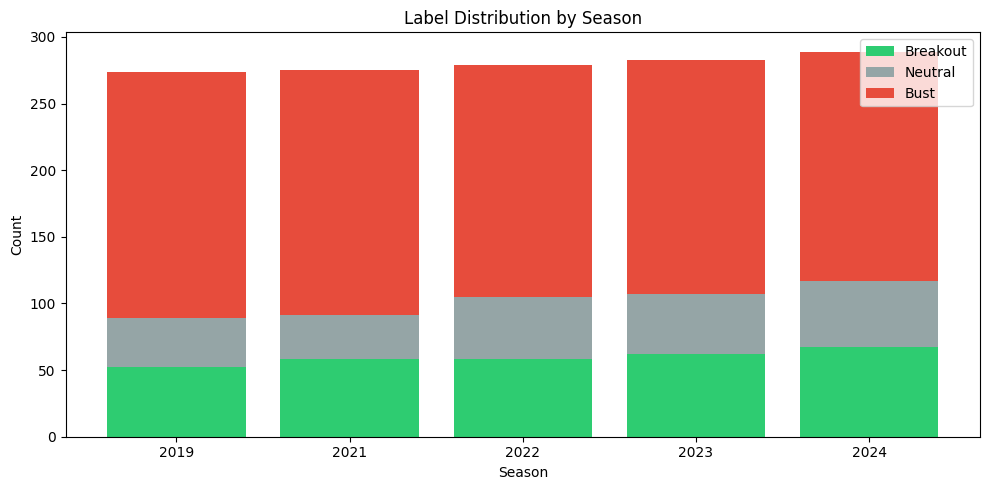

In [3]:
fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(SEASONS))
breakouts = [dist_df.loc[i, "breakout"] for i in range(len(SEASONS))]
neutrals = [dist_df.loc[i, "neutral"] for i in range(len(SEASONS))]
busts = [dist_df.loc[i, "bust"] for i in range(len(SEASONS))]

ax.bar(x, breakouts, label="Breakout", color="#2ecc71")
ax.bar(x, neutrals, bottom=breakouts, label="Neutral", color="#95a5a6")
ax.bar(x, busts, bottom=[b + n for b, n in zip(breakouts, neutrals)], label="Bust", color="#e74c3c")
ax.set_xticks(list(x))
ax.set_xticklabels(SEASONS)
ax.set_xlabel("Season")
ax.set_ylabel("Count")
ax.set_title("Label Distribution by Season")
ax.legend()
plt.tight_layout()
plt.show()

## 2. Model Training & Walk-Forward Evaluation

Train on all seasons before the holdout, predict the holdout, and measure log-loss. We do this for each holdout season (2021-2024) to get a walk-forward view.

In [4]:
def build_joined_rows(seasons, player_type):
    labels = []
    for s in seasons:
        labels.extend(ls for ls in label_source.get_labels(s) if ls.player_type == player_type)
    builder = _FEATURE_SET_BUILDERS[player_type]
    feature_set = builder(seasons)
    handle = assembler.get_or_materialize(feature_set)
    rows = assembler.read(handle)
    return _join_labels_with_features(labels, rows)


def train_and_predict(train_seasons, holdout_season, player_type):
    """Train classifier, return raw AND calibrated holdout probabilities."""
    all_seasons = sorted(set(train_seasons) | {holdout_season})
    joined = build_joined_rows(all_seasons, player_type)
    if not joined:
        return None
    feature_columns = _DEFAULT_FEATURE_COLUMNS[player_type]
    train_rows = [r for r in joined if r["season"] != holdout_season]
    holdout_rows = [r for r in joined if r["season"] == holdout_season]
    if not train_rows or not holdout_rows:
        return None

    X_train = extract_features(train_rows, feature_columns)
    y_train = [LABEL_TO_INT[r["label"]] for r in train_rows]
    clf = HistGradientBoostingClassifier(max_iter=200, max_depth=5, learning_rate=0.1, min_samples_leaf=10)
    clf.fit(X_train, y_train)

    X_holdout = extract_features(holdout_rows, feature_columns)
    y_holdout = [LABEL_TO_INT[r["label"]] for r in holdout_rows]
    raw_proba = clf.predict_proba(X_holdout)

    # Map classes
    class_to_idx = {c: i for i, c in enumerate(clf.classes_)}
    breakout_idx = class_to_idx.get(1, 1)
    bust_idx = class_to_idx.get(2, 2)

    # Fit calibrators from CV folds (needs >= 3 seasons in train+holdout)
    cal_proba = raw_proba.copy()
    if len(all_seasons) >= 3:
        fold_data = _collect_classification_fold_data(joined, feature_columns, all_seasons)
        if fold_data:
            calibrators = fit_multifold_calibrators(fold_data, method="isotonic")
            raw_preds = {
                "p_breakout": list(raw_proba[:, breakout_idx]),
                "p_bust": list(raw_proba[:, bust_idx]),
            }
            cal_preds = apply_calibrators(raw_preds, calibrators)
            p_bo = np.array(cal_preds["p_breakout"])
            p_bu = np.array(cal_preds["p_bust"])
            p_bo, p_bu, p_ne = _renormalize_probabilities(p_bo, p_bu)
            # Reconstruct proba array in [neutral, breakout, bust] order
            cal_proba = np.column_stack([p_ne, p_bo, p_bu])

    return {
        "y_true": y_holdout,
        "raw_proba": raw_proba,
        "cal_proba": cal_proba,
        "clf": clf,
        "feat_cols": feature_columns,
        "train_seasons": train_seasons,
        "n": len(y_holdout),
    }


holdout_seasons = [2021, 2022, 2023, 2024]
results = {}

for holdout in holdout_seasons:
    train_seasons = [s for s in SEASONS if s < holdout]
    if not train_seasons:
        continue
    results[holdout] = {}
    for ptype in ("batter", "pitcher"):
        r = train_and_predict(train_seasons, holdout, ptype)
        if r is None:
            continue
        # Compute log-loss for both raw and calibrated
        r["raw_log_loss"] = log_loss(r["y_true"], r["raw_proba"], labels=[0, 1, 2])
        r["cal_log_loss"] = log_loss(r["y_true"], r["cal_proba"], labels=[0, 1, 2])
        n = r["n"]
        base_proba = np.zeros((n, 3))
        y_arr = np.array(r["y_true"])
        for c in range(3):
            base_proba[:, c] = np.sum(y_arr == c) / n
        r["base_rate_log_loss"] = log_loss(r["y_true"], base_proba, labels=[0, 1, 2])
        results[holdout][ptype] = r

print("Walk-forward training complete (raw + calibrated).")

Walk-forward training complete (raw + calibrated).


## 3. Log-Loss: Raw vs Calibrated vs Base-Rate

**Before calibration**, the model had log-loss ratios of 2.5-3.2x (much worse than base rate).
Post-hoc isotonic calibration should bring the ratio closer to or below 1.0.

 holdout    type   n               train_on  raw_log_loss  cal_log_loss  base_rate_ll  raw_ratio  cal_ratio
    2021  batter 208                   2019        2.0293        2.0293        0.7000     2.8991     2.8991
    2021 pitcher  67                   2019        2.4361        2.4361        1.0005     2.4350     2.4350
    2022  batter 162             2019, 2021        2.9382        1.9244        0.9512     3.0890     2.0231
    2022 pitcher 117             2019, 2021        4.0495        2.8856        0.8579     4.7205     3.3638
    2023  batter 165       2019, 2021, 2022        2.4719        0.9751        0.9486     2.6058     1.0279
    2023 pitcher 118       2019, 2021, 2022        2.1375        1.9702        0.8287     2.5792     2.3774
    2024  batter 176 2019, 2021, 2022, 2023        2.4032        1.0087        0.9807     2.4504     1.0285
    2024 pitcher 113 2019, 2021, 2022, 2023        2.1302        0.8337        0.8341     2.5539     0.9995

--- Calibration Impact Summ

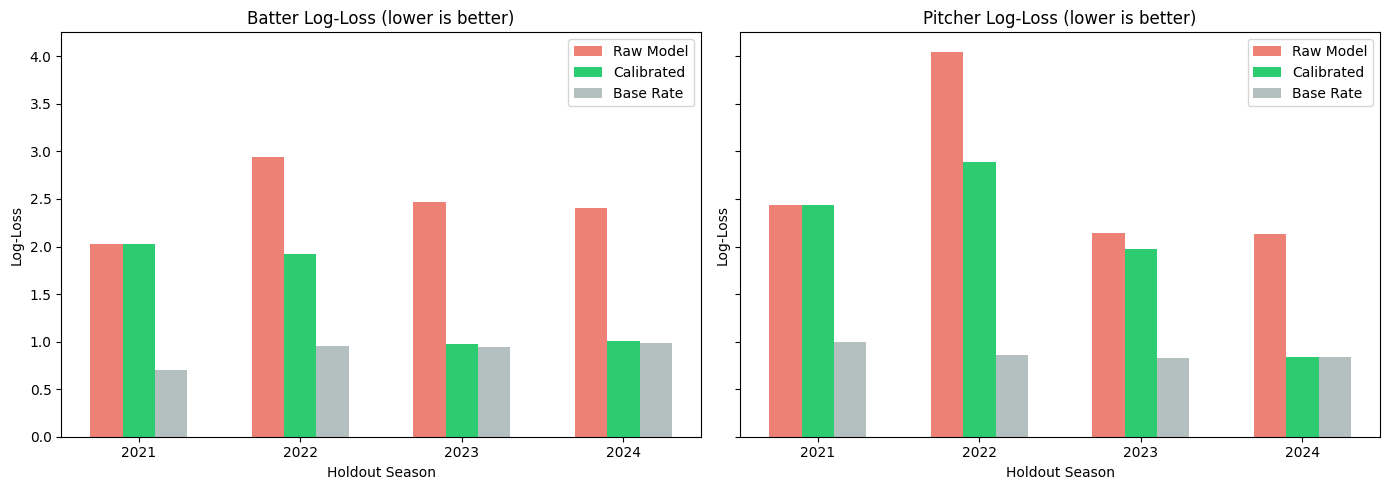

In [5]:
ll_rows = []
for holdout in sorted(results.keys()):
    for ptype in ("batter", "pitcher"):
        if ptype not in results[holdout]:
            continue
        r = results[holdout][ptype]
        ll_rows.append(
            {
                "holdout": holdout,
                "type": ptype,
                "n": r["n"],
                "train_on": ", ".join(map(str, r["train_seasons"])),
                "raw_log_loss": round(r["raw_log_loss"], 4),
                "cal_log_loss": round(r["cal_log_loss"], 4),
                "base_rate_ll": round(r["base_rate_log_loss"], 4),
                "raw_ratio": round(r["raw_log_loss"] / r["base_rate_log_loss"], 4)
                if r["base_rate_log_loss"] > 0
                else None,
                "cal_ratio": round(r["cal_log_loss"] / r["base_rate_log_loss"], 4)
                if r["base_rate_log_loss"] > 0
                else None,
            }
        )

ll_df = pd.DataFrame(ll_rows)
print(ll_df.to_string(index=False))

# Summary improvement
print("\n--- Calibration Impact Summary ---")
for ptype in ("batter", "pitcher"):
    sub = ll_df[ll_df["type"] == ptype]
    mean_raw = sub["raw_ratio"].mean()
    mean_cal = sub["cal_ratio"].mean()
    print(f"  {ptype.upper()}: raw ratio={mean_raw:.4f} -> cal ratio={mean_cal:.4f}  (Δ={mean_cal - mean_raw:+.4f})")

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, ptype in zip(axes, ("batter", "pitcher")):
    sub = ll_df[ll_df["type"] == ptype]
    x = range(len(sub))
    ax.bar([i - 0.2 for i in x], sub["raw_log_loss"], width=0.2, label="Raw Model", color="#e74c3c", alpha=0.7)
    ax.bar([i for i in x], sub["cal_log_loss"], width=0.2, label="Calibrated", color="#2ecc71")
    ax.bar([i + 0.2 for i in x], sub["base_rate_ll"], width=0.2, label="Base Rate", color="#95a5a6", alpha=0.7)
    ax.set_xticks(list(x))
    ax.set_xticklabels(sub["holdout"].values)
    ax.set_xlabel("Holdout Season")
    ax.set_ylabel("Log-Loss")
    ax.set_title(f"{ptype.title()} Log-Loss (lower is better)")
    ax.legend()
plt.tight_layout()
plt.show()

## 4. Threshold Metrics (Precision / Recall / F1)

For each probability threshold, how many players are flagged and what fraction are true breakouts/busts? Pooled across all holdout seasons.

In [6]:
thresholds = [0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50]

for ptype in ("batter", "pitcher"):
    print(f"\n{'=' * 70}")
    print(f"  {ptype.upper()} -- Threshold Metrics (CALIBRATED, pooled across holdout seasons)")
    print(f"{'=' * 70}")
    y_all, proba_all = [], []
    for holdout in sorted(results.keys()):
        if ptype in results[holdout]:
            r = results[holdout][ptype]
            y_all.extend(r["y_true"])
            proba_all.append(r["cal_proba"])
    if not y_all:
        print("  No data")
        continue
    y_arr = np.array(y_all)
    proba_arr = np.vstack(proba_all)
    for label_name, label_int in [("breakout", 1), ("bust", 2)]:
        rows = []
        actual_pos = int(np.sum(y_arr == label_int))
        for thresh in thresholds:
            flagged_mask = proba_arr[:, label_int] >= thresh
            flagged = int(np.sum(flagged_mask))
            tp = int(np.sum(flagged_mask & (y_arr == label_int)))
            precision = tp / flagged if flagged > 0 else 0
            recall = tp / actual_pos if actual_pos > 0 else 0
            f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
            rows.append(
                {
                    "threshold": thresh,
                    "flagged": flagged,
                    "true_pos": tp,
                    "precision": f"{precision:.1%}",
                    "recall": f"{recall:.1%}",
                    "f1": f"{f1:.3f}",
                }
            )
        print(f"\n  {label_name.upper()} (actual positives: {actual_pos})")
        print(pd.DataFrame(rows).to_string(index=False))


  BATTER -- Threshold Metrics (CALIBRATED, pooled across holdout seasons)

  BREAKOUT (actual positives: 120)
 threshold  flagged  true_pos precision recall    f1
      0.10      316        83     26.3%  69.2% 0.381
      0.15      295        81     27.5%  67.5% 0.390
      0.20      253        72     28.5%  60.0% 0.386
      0.25      198        65     32.8%  54.2% 0.409
      0.30      166        57     34.3%  47.5% 0.399
      0.40       44        17     38.6%  14.2% 0.207
      0.50       33        12     36.4%  10.0% 0.157

  BUST (actual positives: 456)
 threshold  flagged  true_pos precision recall    f1
      0.10      709       454     64.0%  99.6% 0.779
      0.15      708       453     64.0%  99.3% 0.778
      0.20      708       453     64.0%  99.3% 0.778
      0.25      706       452     64.0%  99.1% 0.778
      0.30      703       450     64.0%  98.7% 0.777
      0.40      673       436     64.8%  95.6% 0.772
      0.50      633       417     65.9%  91.4% 0.766

  PITCHE

## 5. Lift Analysis

How much better than random is the model at identifying breakouts/busts in the top-N flagged candidates?

In [7]:
top_ns = [10, 20, 50]

for ptype in ("batter", "pitcher"):
    print(f"\n{'=' * 60}")
    print(f"  {ptype.upper()} -- Lift Analysis (CALIBRATED)")
    print(f"{'=' * 60}")
    y_all, proba_all = [], []
    for holdout in sorted(results.keys()):
        if ptype in results[holdout]:
            r = results[holdout][ptype]
            y_all.extend(r["y_true"])
            proba_all.append(r["cal_proba"])
    if not y_all:
        continue
    y_arr = np.array(y_all)
    proba_arr = np.vstack(proba_all)
    n = len(y_arr)
    for label_name, label_int in [("breakout", 1), ("bust", 2)]:
        actual_count = int(np.sum(y_arr == label_int))
        base_rate = actual_count / n
        sorted_idx = np.argsort(-proba_arr[:, label_int])
        rows = []
        for top_n in top_ns:
            eff_n = min(top_n, n)
            top_indices = sorted_idx[:eff_n]
            top_actual = int(np.sum(y_arr[top_indices] == label_int))
            flagged_rate = top_actual / eff_n
            lift = flagged_rate / base_rate if base_rate > 0 else 0
            rows.append(
                {
                    "top_n": top_n,
                    "hits": top_actual,
                    "hit_rate": f"{flagged_rate:.1%}",
                    "base_rate": f"{base_rate:.1%}",
                    "lift": f"{lift:.2f}x",
                }
            )
        print(f"\n  {label_name.upper()} (base rate: {base_rate:.1%}, {actual_count}/{n})")
        print(pd.DataFrame(rows).to_string(index=False))


  BATTER -- Lift Analysis (CALIBRATED)

  BREAKOUT (base rate: 16.9%, 120/711)
 top_n  hits hit_rate base_rate  lift
    10     4    40.0%     16.9% 2.37x
    20     7    35.0%     16.9% 2.07x
    50    19    38.0%     16.9% 2.25x

  BUST (base rate: 64.1%, 456/711)
 top_n  hits hit_rate base_rate  lift
    10    10   100.0%     64.1% 1.56x
    20    19    95.0%     64.1% 1.48x
    50    48    96.0%     64.1% 1.50x

  PITCHER -- Lift Analysis (CALIBRATED)

  BREAKOUT (base rate: 30.1%, 125/415)
 top_n  hits hit_rate base_rate  lift
    10     6    60.0%     30.1% 1.99x
    20    12    60.0%     30.1% 1.99x
    50    26    52.0%     30.1% 1.73x

  BUST (base rate: 60.2%, 250/415)
 top_n  hits hit_rate base_rate  lift
    10     7    70.0%     60.2% 1.16x
    20    12    60.0%     60.2% 1.00x
    50    28    56.0%     60.2% 0.93x


## 6. Calibration Reliability Diagrams (Before vs After)

Side-by-side comparison: raw model (left) vs calibrated model (right). Points closer to the diagonal = better calibration.

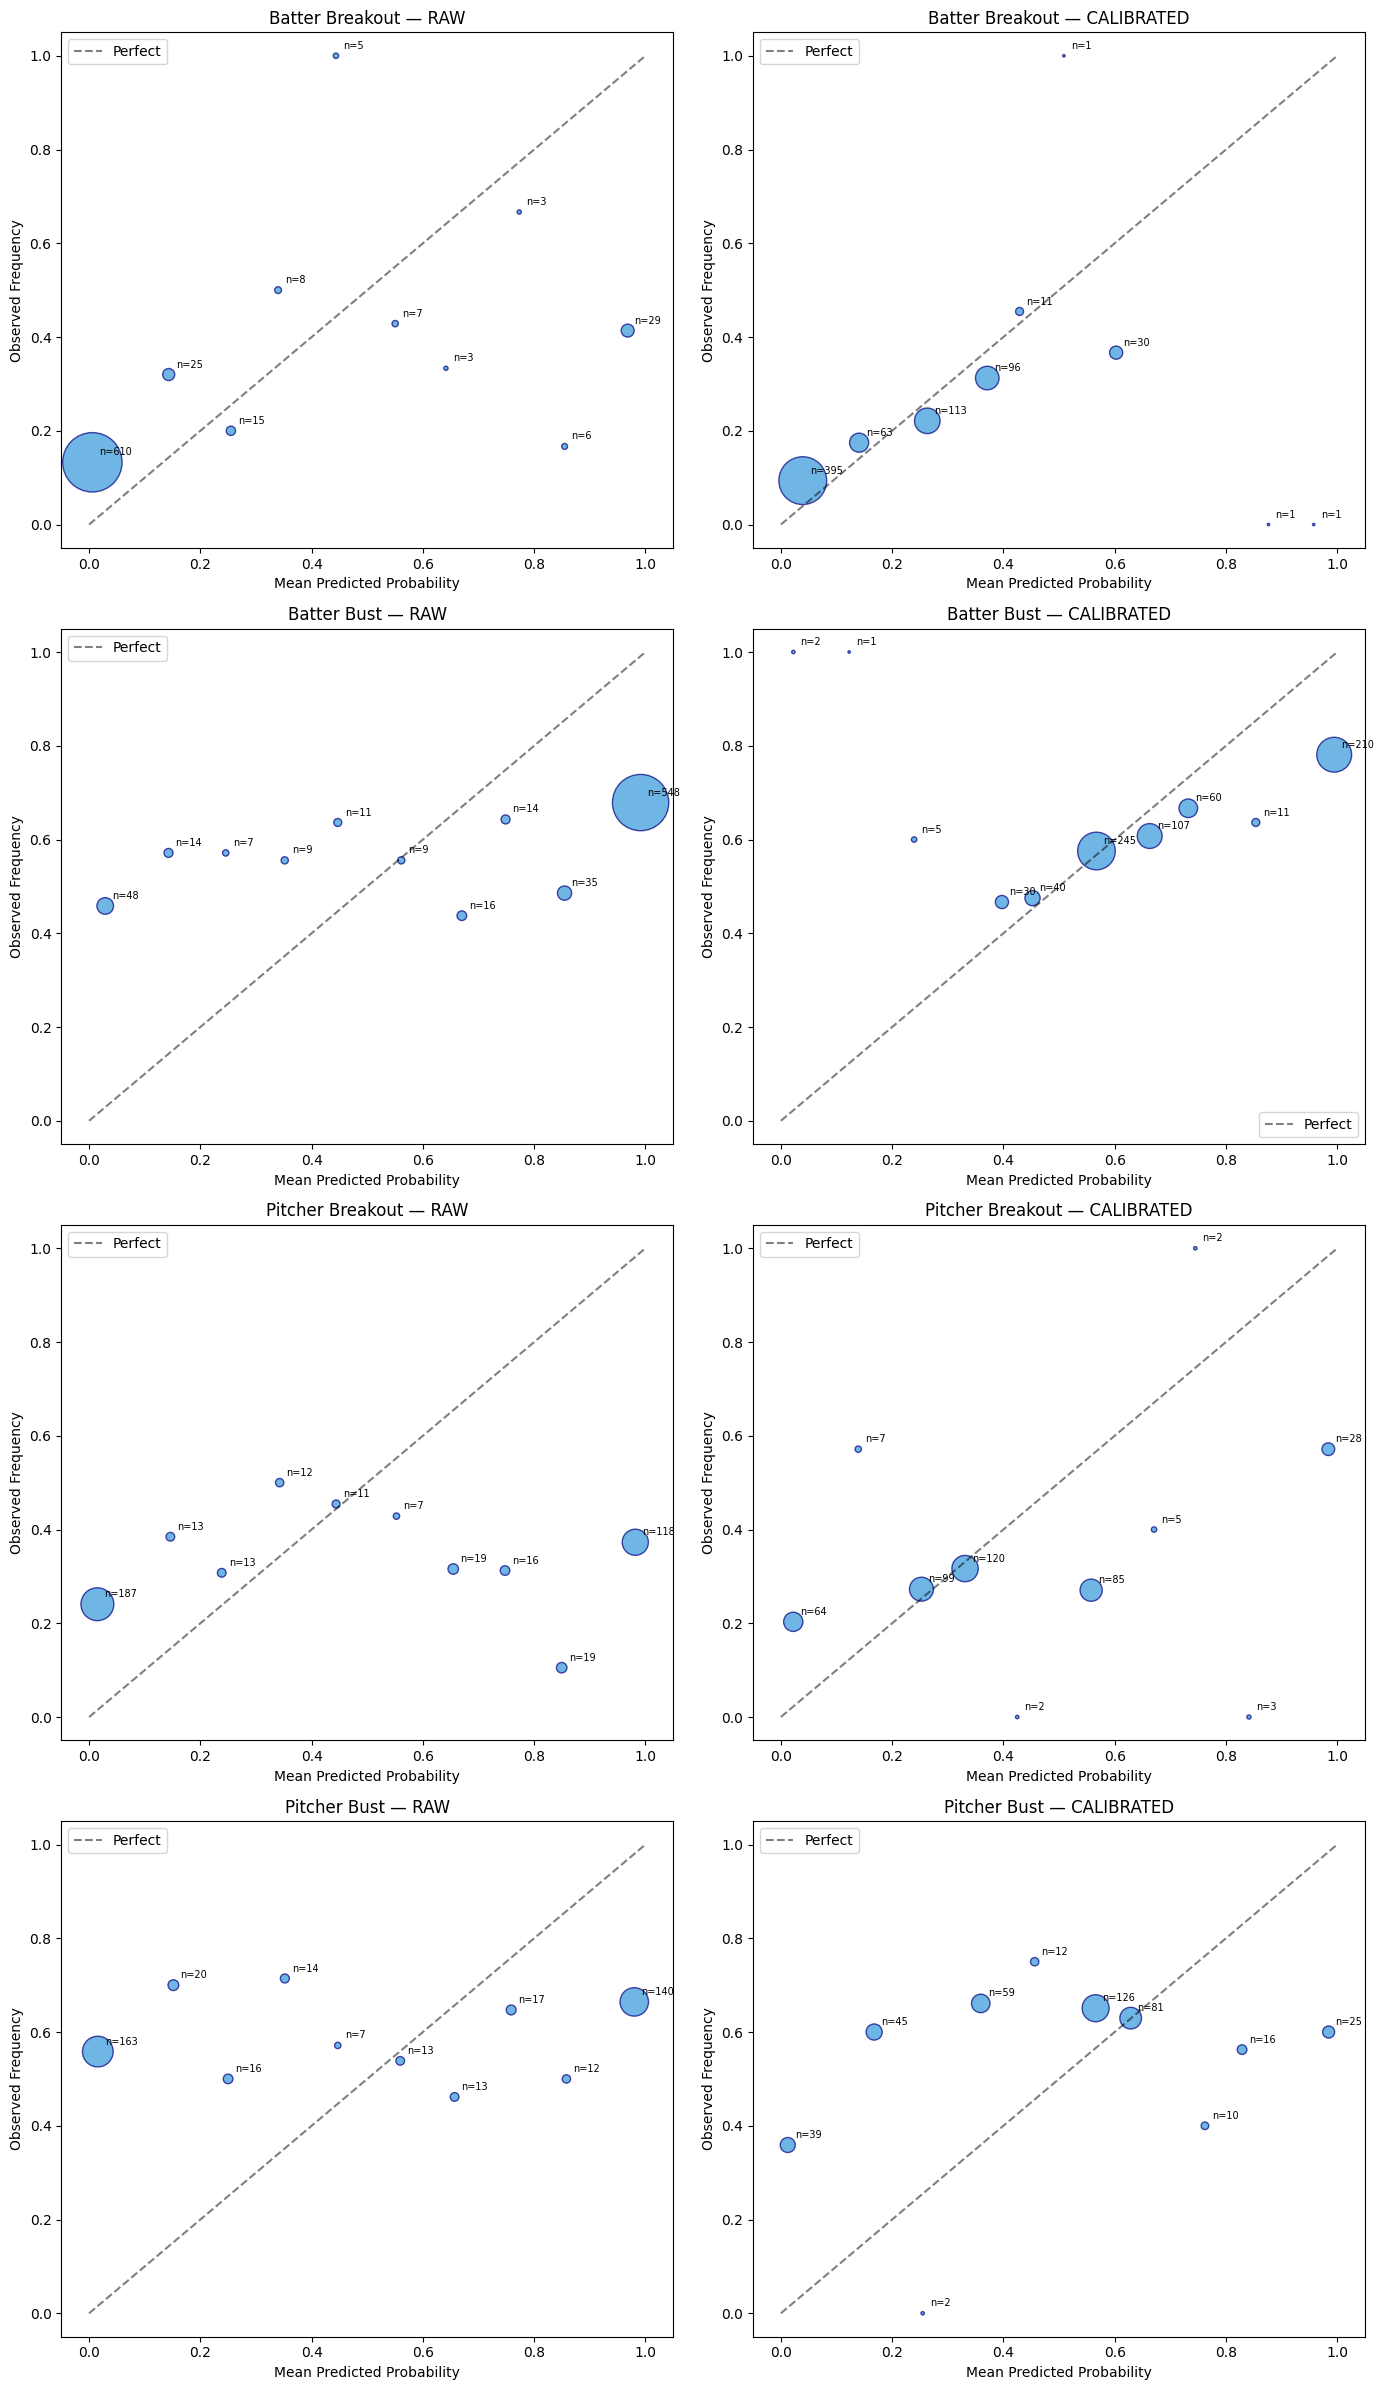

In [8]:
def plot_reliability(ax, probs, actuals, title):
    """Plot a reliability diagram on the given axis."""
    bin_edges = np.linspace(0, 1, 11)
    mean_preds, mean_acts, counts = [], [], []
    for i in range(10):
        low, high = bin_edges[i], bin_edges[i + 1]
        mask = (probs >= low) & (probs <= high) if i == 9 else (probs >= low) & (probs < high)
        if mask.sum() > 0:
            mean_preds.append(probs[mask].mean())
            mean_acts.append(actuals[mask].mean())
            counts.append(int(mask.sum()))
    ax.plot([0, 1], [0, 1], "k--", alpha=0.5, label="Perfect")
    ax.scatter(mean_preds, mean_acts, s=[c * 3 for c in counts], alpha=0.7, c="#3498db", edgecolors="navy")
    ax.set_xlabel("Mean Predicted Probability")
    ax.set_ylabel("Observed Frequency")
    ax.set_title(title)
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)
    ax.legend()
    for xv, yv, c in zip(mean_preds, mean_acts, counts):
        ax.annotate(f"n={c}", (xv, yv), textcoords="offset points", xytext=(5, 5), fontsize=7)


fig, axes = plt.subplots(4, 2, figsize=(14, 24))

for row_base, ptype in enumerate(("batter", "pitcher")):
    y_all, raw_all, cal_all = [], [], []
    for holdout in sorted(results.keys()):
        if ptype in results[holdout]:
            r = results[holdout][ptype]
            y_all.extend(r["y_true"])
            raw_all.append(r["raw_proba"])
            cal_all.append(r["cal_proba"])
    if not y_all:
        continue
    y_arr = np.array(y_all)
    raw_arr = np.vstack(raw_all)
    cal_arr = np.vstack(cal_all)

    for label_offset, (label_name, label_int) in enumerate([("breakout", 1), ("bust", 2)]):
        ax_row = row_base * 2 + label_offset
        actuals = (y_arr == label_int).astype(float)
        # Raw (left)
        plot_reliability(axes[ax_row, 0], raw_arr[:, label_int], actuals, f"{ptype.title()} {label_name.title()} — RAW")
        # Calibrated (right)
        plot_reliability(
            axes[ax_row, 1], cal_arr[:, label_int], actuals, f"{ptype.title()} {label_name.title()} — CALIBRATED"
        )

plt.tight_layout()
plt.show()

## 7. Feature Importances

Permutation-based feature importances from the final model (trained on 2019-2023, holdout 2024).

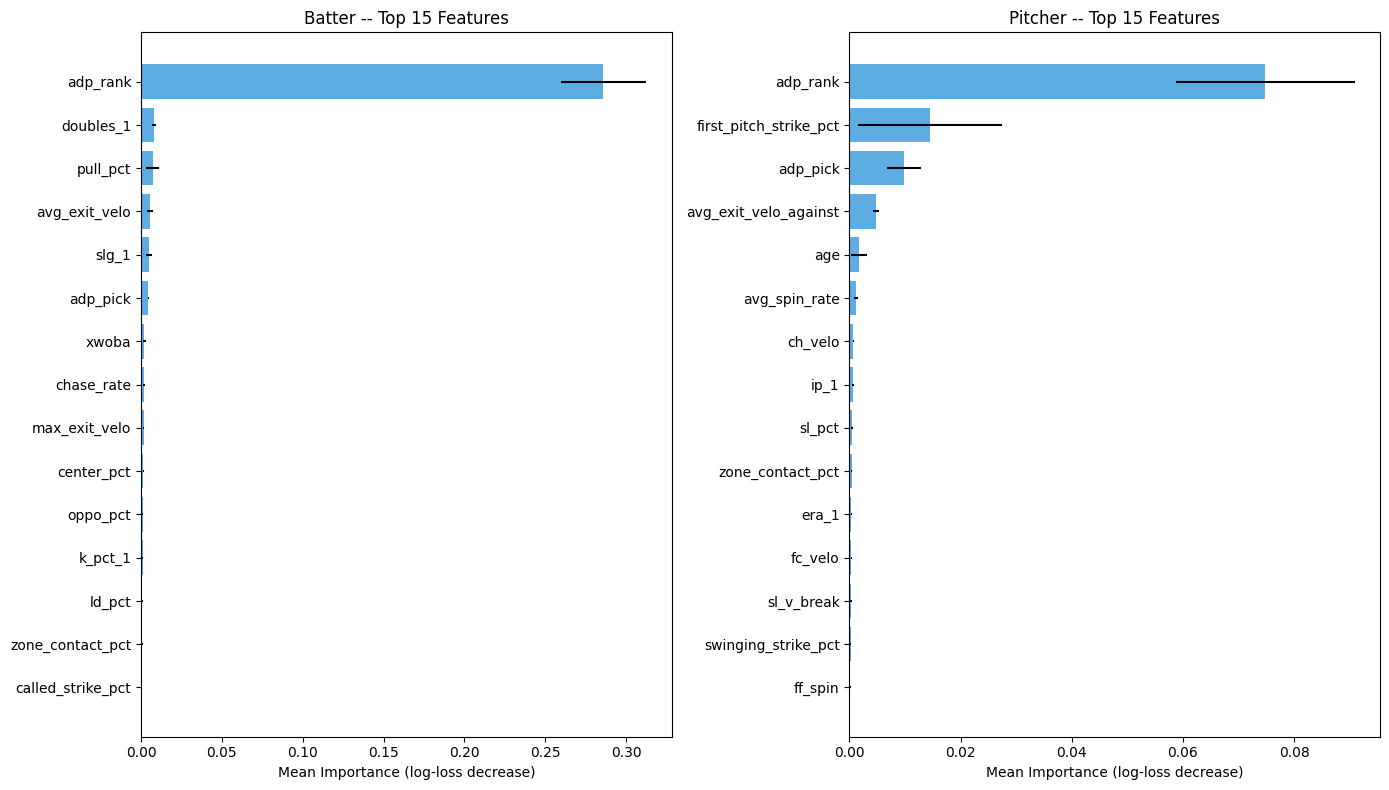

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 8))

for ax, ptype in zip(axes, ("batter", "pitcher")):
    if 2024 not in results or ptype not in results[2024]:
        ax.set_title(f"{ptype.title()} -- No data")
        continue
    r = results[2024][ptype]
    clf = r["clf"]
    feat_cols = r["feat_cols"]
    train_seasons = r["train_seasons"]
    all_seasons = sorted(set(train_seasons) | {2024})
    joined = build_joined_rows(all_seasons, ptype)
    train_rows = [row for row in joined if row["season"] != 2024]
    X_train = np.array(extract_features(train_rows, feat_cols), dtype=np.float64)
    y_train = np.array([LABEL_TO_INT[row["label"]] for row in train_rows])
    result = permutation_importance(clf, X_train, y_train, n_repeats=10, random_state=42, scoring="neg_log_loss")
    sorted_idx = np.argsort(result.importances_mean)[::-1][:15]
    names = [feat_cols[i] for i in sorted_idx]
    importances = result.importances_mean[sorted_idx]
    stds = result.importances_std[sorted_idx]
    y_pos = range(len(names))
    ax.barh(y_pos, importances, xerr=stds, align="center", color="#3498db", alpha=0.8)
    ax.set_yticks(list(y_pos))
    ax.set_yticklabels(names)
    ax.invert_yaxis()
    ax.set_xlabel("Mean Importance (log-loss decrease)")
    ax.set_title(f"{ptype.title()} -- Top 15 Features")
plt.tight_layout()
plt.show()

## 8. Temporal CV Log-Loss Stability

Expanding-window cross-validation: train on seasons up to t-1, test on season t. Shows how stable the model is across time.


BATTER -- Temporal CV Folds
  type            train  test  n_test  raw_ll  cal_ll  base_ll  raw_ratio  cal_ratio
batter             2019  2021     208  2.0293  2.0293   0.7000     2.8991     2.8991
batter       2019, 2021  2022     162  2.9382  1.9244   0.9512     3.0890     2.0231
batter 2019, 2021, 2022  2023     165  2.6977  1.7681   0.9486     2.8438     1.8639
  Mean raw ratio:  2.9440
  Mean cal ratio:  2.2620

PITCHER -- Temporal CV Folds
   type            train  test  n_test  raw_ll  cal_ll  base_ll  raw_ratio  cal_ratio
pitcher             2019  2021      67  2.4361  2.4361   1.0005     2.4350     2.4350
pitcher       2019, 2021  2022     117  4.0495  2.8856   0.8579     4.7205     3.3638
pitcher 2019, 2021, 2022  2023     118  2.1375  1.9702   0.8287     2.5792     2.3774
  Mean raw ratio:  3.2449
  Mean cal ratio:  2.7254


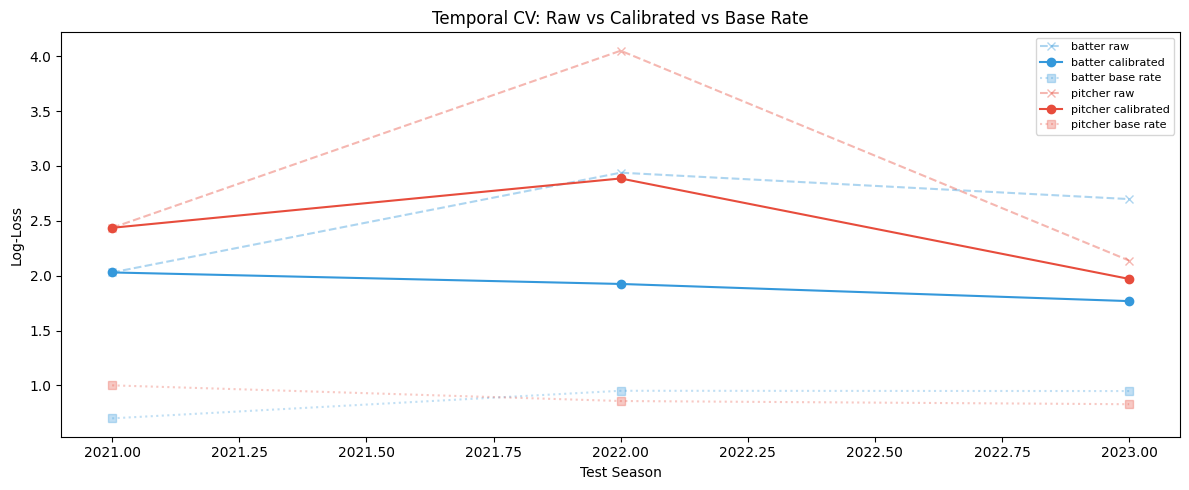

In [10]:
cv_results = []

for ptype in ("batter", "pitcher"):
    joined = build_joined_rows(SEASONS, ptype)
    if not joined:
        continue
    feature_columns = _DEFAULT_FEATURE_COLUMNS[ptype]
    for train_seasons, test_season in temporal_expanding_cv(SEASONS):
        train_rows = [r for r in joined if r["season"] in set(train_seasons)]
        test_rows = [r for r in joined if r["season"] == test_season]
        if not train_rows or not test_rows:
            continue
        X_train = extract_features(train_rows, feature_columns)
        y_train = [LABEL_TO_INT[r["label"]] for r in train_rows]
        X_test = extract_features(test_rows, feature_columns)
        y_test = [LABEL_TO_INT[r["label"]] for r in test_rows]

        clf = HistGradientBoostingClassifier(max_iter=200, max_depth=5, learning_rate=0.1, min_samples_leaf=10)
        clf.fit(X_train, y_train)
        raw_proba = clf.predict_proba(X_test)
        raw_ll = log_loss(y_test, raw_proba, labels=[0, 1, 2])

        # Calibrate
        all_seasons_for_cv = sorted(set(train_seasons) | {test_season})
        cal_proba = raw_proba.copy()
        if len(all_seasons_for_cv) >= 3:
            fold_data = _collect_classification_fold_data(joined, feature_columns, all_seasons_for_cv)
            if fold_data:
                calibrators = fit_multifold_calibrators(fold_data, method="isotonic")
                class_to_idx = {c: i for i, c in enumerate(clf.classes_)}
                breakout_idx = class_to_idx.get(1, 1)
                bust_idx = class_to_idx.get(2, 2)
                raw_preds = {
                    "p_breakout": list(raw_proba[:, breakout_idx]),
                    "p_bust": list(raw_proba[:, bust_idx]),
                }
                cal_preds = apply_calibrators(raw_preds, calibrators)
                p_bo = np.array(cal_preds["p_breakout"])
                p_bu = np.array(cal_preds["p_bust"])
                p_bo, p_bu, p_ne = _renormalize_probabilities(p_bo, p_bu)
                cal_proba = np.column_stack([p_ne, p_bo, p_bu])

        cal_ll = log_loss(y_test, cal_proba, labels=[0, 1, 2])

        n = len(y_test)
        base_proba = np.zeros((n, 3))
        y_arr = np.array(y_test)
        for c in range(3):
            base_proba[:, c] = np.sum(y_arr == c) / n
        base_ll = log_loss(y_test, base_proba, labels=[0, 1, 2])

        cv_results.append(
            {
                "type": ptype,
                "train": ", ".join(map(str, train_seasons)),
                "test": test_season,
                "n_test": len(test_rows),
                "raw_ll": round(raw_ll, 4),
                "cal_ll": round(cal_ll, 4),
                "base_ll": round(base_ll, 4),
                "raw_ratio": round(raw_ll / base_ll, 4) if base_ll > 0 else None,
                "cal_ratio": round(cal_ll / base_ll, 4) if base_ll > 0 else None,
            }
        )

cv_df = pd.DataFrame(cv_results)
for ptype in ("batter", "pitcher"):
    sub = cv_df[cv_df["type"] == ptype]
    print(f"\n{ptype.upper()} -- Temporal CV Folds")
    print(sub.to_string(index=False))
    print(f"  Mean raw ratio:  {sub['raw_ratio'].mean():.4f}")
    print(f"  Mean cal ratio:  {sub['cal_ratio'].mean():.4f}")

fig, ax = plt.subplots(figsize=(12, 5))
for ptype, color in [("batter", "#3498db"), ("pitcher", "#e74c3c")]:
    sub = cv_df[cv_df["type"] == ptype]
    ax.plot(sub["test"].values, sub["raw_ll"].values, "x--", label=f"{ptype} raw", color=color, alpha=0.4)
    ax.plot(sub["test"].values, sub["cal_ll"].values, "o-", label=f"{ptype} calibrated", color=color)
    ax.plot(sub["test"].values, sub["base_ll"].values, "s:", label=f"{ptype} base rate", color=color, alpha=0.3)
ax.set_xlabel("Test Season")
ax.set_ylabel("Log-Loss")
ax.set_title("Temporal CV: Raw vs Calibrated vs Base Rate")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 9. Probability Distribution (Histograms)

How are the predicted probabilities distributed? A model that only predicts near the base rate has little discriminative power.

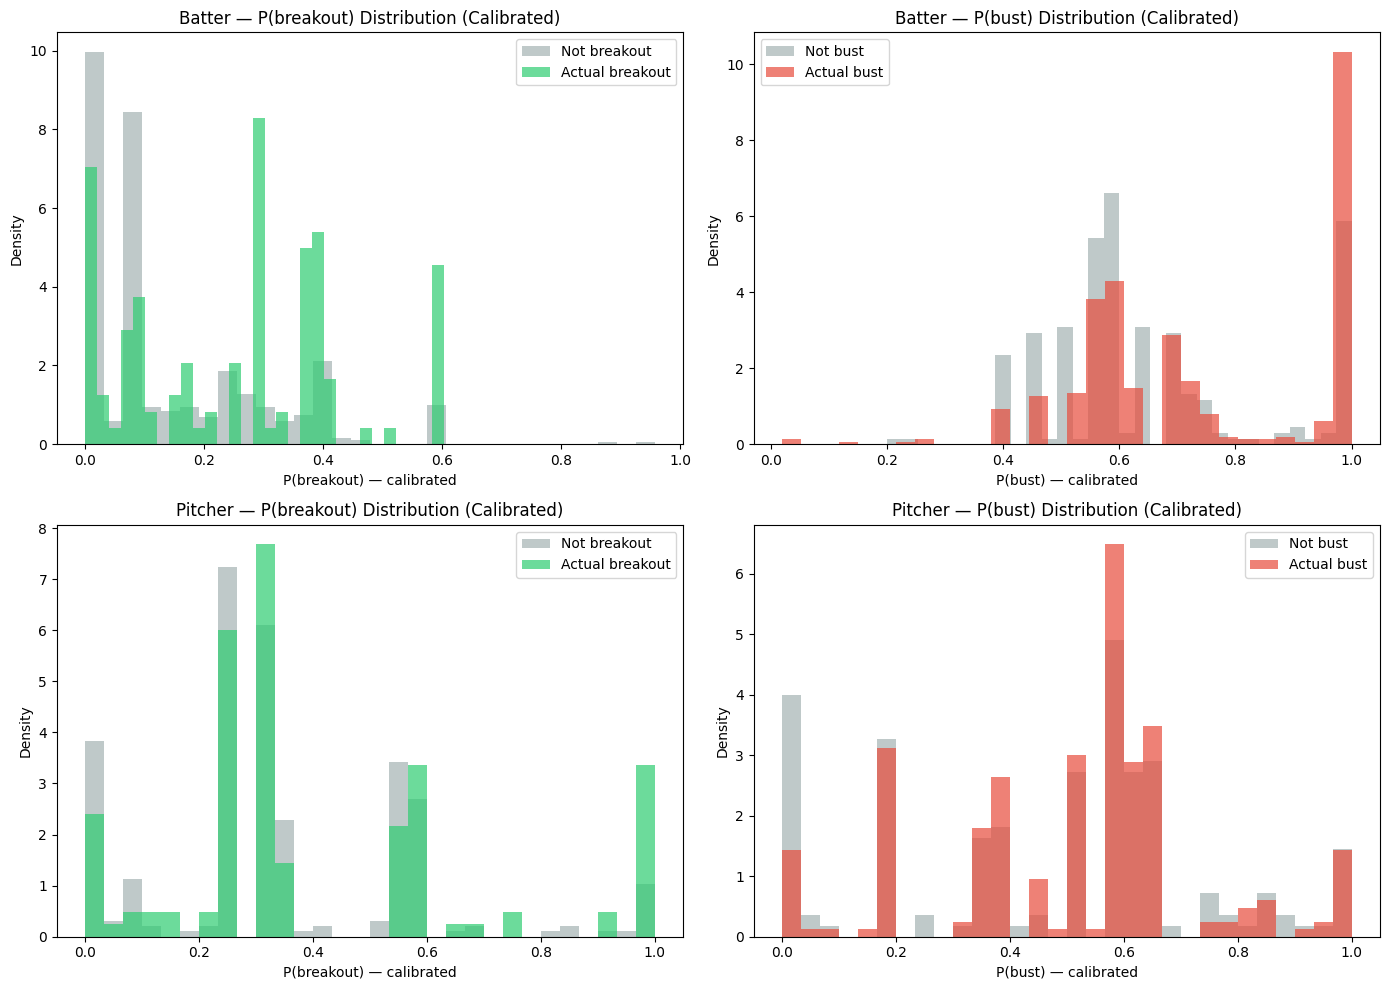

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for row, ptype in enumerate(("batter", "pitcher")):
    y_all, proba_all = [], []
    for holdout in sorted(results.keys()):
        if ptype in results[holdout]:
            r = results[holdout][ptype]
            y_all.extend(r["y_true"])
            proba_all.append(r["cal_proba"])
    if not y_all:
        continue
    y_arr = np.array(y_all)
    proba_arr = np.vstack(proba_all)
    for col, (label_name, label_int) in enumerate([("breakout", 1), ("bust", 2)]):
        ax = axes[row, col]
        probs = proba_arr[:, label_int]
        pos_mask = y_arr == label_int
        ax.hist(probs[~pos_mask], bins=30, alpha=0.6, label=f"Not {label_name}", color="#95a5a6", density=True)
        ax.hist(
            probs[pos_mask],
            bins=30,
            alpha=0.7,
            label=f"Actual {label_name}",
            color="#2ecc71" if label_name == "breakout" else "#e74c3c",
            density=True,
        )
        ax.set_xlabel(f"P({label_name}) — calibrated")
        ax.set_ylabel("Density")
        ax.set_title(f"{ptype.title()} — P({label_name}) Distribution (Calibrated)")
        ax.legend()
plt.tight_layout()
plt.show()

## 10. Summary

In [12]:
print("=" * 70)
print("  BREAKOUT/BUST CLASSIFIER — CALIBRATION IMPACT SUMMARY")
print("=" * 70)

for ptype in ("batter", "pitcher"):
    sub = cv_df[cv_df["type"] == ptype]
    if sub.empty:
        continue
    mean_raw_ratio = sub["raw_ratio"].mean()
    mean_cal_ratio = sub["cal_ratio"].mean()
    print(f"\n  {ptype.upper()}")
    print(f"    CV mean raw ratio:      {mean_raw_ratio:.4f}")
    print(f"    CV mean cal ratio:      {mean_cal_ratio:.4f}")
    improvement = (1 - mean_cal_ratio / mean_raw_ratio) * 100
    print(f"    Improvement:            {improvement:+.1f}%")
    if 2024 in results and ptype in results[2024]:
        r = results[2024][ptype]
        raw_ratio = r["raw_log_loss"] / r["base_rate_log_loss"]
        cal_ratio = r["cal_log_loss"] / r["base_rate_log_loss"]
        print(f"    2024 raw ratio:         {raw_ratio:.4f}")
        print(f"    2024 cal ratio:         {cal_ratio:.4f}")
        status = "BEATS" if cal_ratio < 1.0 else "loses to"
        print(f"    2024 calibrated {status} base rate")

print("\n" + "=" * 70)
print("  Interpretation guide:")
print("    ratio < 1.0  ->  model adds signal beyond class frequencies")
print("    ratio ~1.0   ->  calibrated probabilities match observed rates")
print("    lift > 1.0x  ->  top-N flagged candidates enrich for true positives")
print("    calibration  ->  points near diagonal = well-calibrated probabilities")
print("=" * 70)

  BREAKOUT/BUST CLASSIFIER — CALIBRATION IMPACT SUMMARY

  BATTER
    CV mean raw ratio:      2.9440
    CV mean cal ratio:      2.2620
    Improvement:            +23.2%
    2024 raw ratio:         2.4504
    2024 cal ratio:         1.0285
    2024 calibrated loses to base rate

  PITCHER
    CV mean raw ratio:      3.2449
    CV mean cal ratio:      2.7254
    Improvement:            +16.0%
    2024 raw ratio:         2.5539
    2024 cal ratio:         0.9995
    2024 calibrated BEATS base rate

  Interpretation guide:
    ratio < 1.0  ->  model adds signal beyond class frequencies
    ratio ~1.0   ->  calibrated probabilities match observed rates
    lift > 1.0x  ->  top-N flagged candidates enrich for true positives
    calibration  ->  points near diagonal = well-calibrated probabilities
